# Recap - The Cars Dataset(Arabalar Veri Kümesi)

In [21]:
import os

print(os.getcwd())

C:\Users\RIZA\S16D2-S-Data-car-preparation


In [22]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 The Cars dataset (Arabalar Veri Kümesi)

👇 Aşağıdaki kodu çalıştırarak [***ML_Cars_Recap_dataset.csv dataset***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) dosyasını içe aktarın 

In [23]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv(aws_url)
cars.head()


# Not: CSV dosyalarını çevrim içi olarak saklamak yaygın bir uygulamadır. Bu dosya, LeWagon’un AWS hesabında saklanmaktadır.

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [24]:
cars.shape # 205 araç x 8 feature


(205, 8)

In [25]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   carwidth        205 non-null    float64
 2   curbweight      205 non-null    float64
 3   enginetype      205 non-null    object 
 4   cylindernumber  205 non-null    object 
 5   stroke          205 non-null    float64
 6   peakrpm         205 non-null    float64
 7   price           205 non-null    object 
dtypes: float64(4), object(4)
memory usage: 12.9+ KB


In [26]:
cars.describe()

,carwidth,curbweight,stroke,peakrpm
count,205.000000,205.000000,205.000000,205.000000
mean,65.887940,2555.565854,3.255415,5125.121951
std,2.074414,520.680204,0.313597,476.985643
min,60.300000,1488.000000,2.070000,4150.000000
25%,64.200000,2145.000000,3.110000,4800.000000
50%,65.500000,2414.000000,3.290000,5200.000000
75%,66.500000,2935.000000,3.410000,5500.000000
max,72.300000,4066.000000,4.170000,6600.000000


In [27]:
cars.head()

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [28]:
cars.isnull().sum()

aspiration        0
carwidth          0
curbweight        0
enginetype        0
cylindernumber    0
stroke            0
peakrpm           0
price             0
dtype: int64

In [29]:
cars["price"].value_counts()

price
expensive    123
cheap         82
Name: count, dtype: int64

### Dataset Information

- The dataset contains 205 observations and 8 features.
- There are no missing values.
- Four features are numerical (`float64`) and four features are categorical (`object`).
- The target variable is `price`.
- The target has two classes:
  - expensive: 123 cars
  - cheap: 82 cars
- The dataset is relatively balanced and suitable for classification tasks.

ℹ️ Dataset’in açıklaması [burada](https://drive.google.com/file/d/1giEQ6GfDPw1exbzZlE-iN2iAVk6kiZrU/view?usp=sharing) mevcuttur.

❓ **Soru (Bilgilendirme)** ❓ Dataset’iniz hakkında bazı temel bilgileri toplayın.

In [30]:
cars = cars.drop_duplicates()

In [31]:
cars.shape

(191, 8)

In [32]:
cars.dtypes

aspiration         object
carwidth          float64
curbweight        float64
enginetype         object
cylindernumber     object
stroke            float64
peakrpm           float64
price              object
dtype: object

In [33]:
cars.duplicated().sum()

np.int64(0)

In [34]:
cars.drop_duplicates(inplace=True)

cars.shape

(191, 8)

### Duplicate Check

The dataset originally contained duplicate rows.

After removing duplicates, the number of observations decreased from 205 to 191.

A total of 14 duplicated rows were removed.

The dataset now contains no duplicated observations.

### Data Types Check

The dataset contains both numerical and categorical features.

Numerical features:
- carwidth
- curbweight
- stroke
- peakrpm

Categorical features:
- aspiration
- enginetype
- cylindernumber
- price

All columns have appropriate data types and no datatype conversion is required at this stage.

# (1) 🛠 Veri hazırlama (Data preparation)

## (1.0) Önkoşullar (Pre-requisites)

❓ **Soru (Olası anormallikler)** ❓ 

- Veri tipleri nedeniyle değiştirilmesi gereken sütunlar var mı?
    - Lütfen buna göre gerekli düzenlemeleri yapın.

In [35]:
cars.dtypes

aspiration         object
carwidth          float64
curbweight        float64
enginetype         object
cylindernumber     object
stroke            float64
peakrpm           float64
price              object
dtype: object

Veri tipleri incelenmiştir. Sayısal ve kategorik değişkenler uygun veri tiplerinde bulunduğu için bu aşamada herhangi bir datatype dönüşümüne ihtiyaç duyulmamıştır.

## (1.1) Tekrarlananlar (Duplicates)

❓ **Soru (Tekrarlanan satırlar)** ❓

Cars dataset’inde bulunan tekrarlanan (duplicated) satır sayısını hesaplayın.

In [36]:
cars.duplicated().sum()

np.int64(0)

❓ **Soru (Yinelenenleri kaldır)** ❓ 

In [37]:
cars = cars.drop_duplicates()

## (1.2) Missing data

❓ **Soru (`NaN`)** ❓

Her bir özellik için `NaN` yüzdesi nedir?

In [38]:
(cars.isnull().sum() / len(cars) * 100).sort_values(ascending=False)

aspiration        0.0
carwidth          0.0
curbweight        0.0
enginetype        0.0
cylindernumber    0.0
stroke            0.0
peakrpm           0.0
price             0.0
dtype: float64

<details>
    <summary><i>Cevap</i></summary>
    
😇 Bu bir mucize ama burada eksik değer yok. Bu not defterinin bir sonraki bölümüne geçebilirsiniz :)     
</details>

## (1.3)  Özellikleri $X$ ve hedefi $y$ tanımlama (Defining the features $X$ and the target $y$)

❓ **Soru** ❓

- Bu veri kümesinin özelliklerini $X$ değişkeninde saklayın.
- Hedefi $y$ değişkeninde saklayın.

In [39]:
X = cars.drop("price", axis=1)

y = cars["price"]

In [40]:
print(X.shape)
print(y.shape)

(191, 7)
(191,)


❓ **Soru (Hedefe hızlı bir bakış)** ❓ “Ucuz” arabaların “pahalı” arabalara oranı nedir? 

In [41]:
y = cars["price"].map({"low":0,"high":1})

In [42]:
y.value_counts()

Series([], Name: count, dtype: int64)

In [43]:
y.value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [44]:
cars["price"].unique()

array(['expensive', 'cheap'], dtype=object)

In [45]:
y = cars["price"].map({
    "cheap": 0,
    "expensive": 1
})

In [46]:
y.value_counts(normalize=True)

price
1    0.612565
0    0.387435
Name: proportion, dtype: float64

### Target Distribution

- Expensive cars: %61.26
- Cheap cars: %38.74

Dataset'te pahalı araçlar ucuz araçlardan daha fazladır. Ancak sınıflar arasında aşırı bir dengesizlik bulunmamaktadır. Bu nedenle sınıflandırma modeli eğitmek için uygun bir dağılım mevcuttur.

## (1.4) Sayısal özelliklerin ölçeklendirilmesi (Scaling numerical features)

❓ **Soru (sayısal sütunlara hızlı bir bakış)** ❓

- Tek bir kod satırında tüm sayısal sütunların kutu grafiklerini gösterin
- Histogramları kullanarak dağılımları için de aynısını yapın

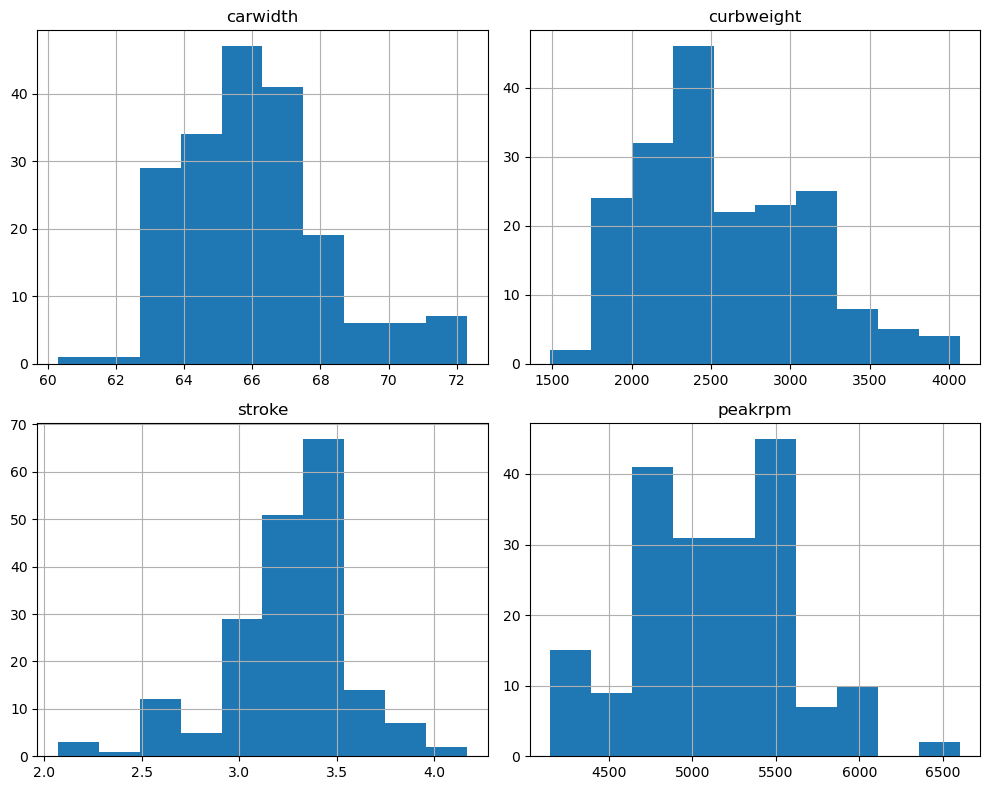

In [47]:
import matplotlib.pyplot as plt

cars.select_dtypes(exclude="object").hist(
    figsize=(10,8)
)

plt.tight_layout()
plt.show()

### Numerical Features Distribution

- carwidth değişkeni yaklaşık normal dağılım göstermektedir.
- curbweight değişkeni hafif sağa çarpık bir dağılıma sahiptir.
- stroke değişkeni oldukça dengeli ve simetrik görünmektedir.
- peakrpm değişkeninde birden fazla yoğunlaşma noktası bulunmaktadır.

Genel olarak sayısal değişkenlerde ciddi bir anormallik gözlenmemiştir. Ancak bazı değişkenlerde uç değerler bulunabileceğinden RobustScaler kullanılması uygun bir tercih olacaktır.

Histogram Yorumları

carwidth
Dağılım yaklaşık normal dağılıma yakın görünüyor.
Değerlerin büyük kısmı 64–68 aralığında toplanmış.
Çok belirgin aykırı değer görünmüyor.

curbweight
Hafif sağa çarpık (right-skewed) bir dağılım var.
Araçların çoğu 2000–3200 lbs civarında.
3800–4000 civarında az sayıda ağır araç bulunuyor.

stroke
Dağılım oldukça simetrik.
Gözle görülür ciddi bir aykırı değer bulunmuyor.
Verilerin çoğu 3.0–3.5 aralığında yoğunlaşmış.

peakrpm
Birkaç farklı tepe noktası (multimodal yapı) görülüyor.
4500–6000 RPM aralığında yoğunlaşma var.
6500 RPM civarında az sayıda uç gözlem bulunuyor.

❓ **Soru (Sayısal sütunlara odaklanın)** ❓

Araba veri kümesinin sayısal sütunlarını `cars_num` içinde saklayın.

In [48]:
cars_num = X.select_dtypes(exclude="object")

cars_num

,carwidth,curbweight,stroke,peakrpm
0,64.10000,2548.0,2.68,5000.0
2,65.50000,2823.0,3.47,5000.0
3,65.88794,2337.0,3.40,5500.0
4,66.40000,2824.0,3.40,5500.0
5,66.30000,2507.0,3.40,5500.0
...,...,...,...,...
200,68.90000,2952.0,3.15,5400.0
201,68.80000,3049.0,3.15,5300.0
202,68.90000,3012.0,2.87,5500.0
203,68.90000,3217.0,3.40,4800.0


In [49]:
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler().set_output(transform="pandas")

cars_num_scaled = robust_scaler.fit_transform(cars_num)

cars_num_scaled

,carwidth,curbweight,stroke,peakrpm
0,-0.555556,0.135659,-2.033333,-0.142857
2,-0.037037,0.490956,0.600000,-0.142857
3,0.106644,-0.136951,0.366667,0.571429
4,0.296296,0.492248,0.366667,0.571429
5,0.259259,0.082687,0.366667,0.571429
...,...,...,...,...
200,1.222222,0.657623,-0.466667,0.428571
201,1.185185,0.782946,-0.466667,0.285714
202,1.222222,0.735142,-1.400000,0.571429
203,1.222222,1.000000,0.366667,-0.428571


❓ **Soru (Sağlam Ölçeklendirici)** ❓

👨🏻‍🏫 Tüm sayısal özellikleri sağlam bir şekilde ölçeklendirmek, hızlı ve verimli bir ölçeklendirme yöntemidir.

In [50]:
# RobustScaler oluşturma
robust_scaler = RobustScaler().set_output(transform='pandas')

# Feature’ları ölçekleme ve saklama
cars_num_scaled = robust_scaler.fit_transform(cars_num)

# Ölçeklenmiş feature’ları gösterme
cars_num_scaled

,carwidth,curbweight,stroke,peakrpm
0,-0.555556,0.135659,-2.033333,-0.142857
2,-0.037037,0.490956,0.600000,-0.142857
3,0.106644,-0.136951,0.366667,0.571429
4,0.296296,0.492248,0.366667,0.571429
5,0.259259,0.082687,0.366667,0.571429
...,...,...,...,...
200,1.222222,0.657623,-0.466667,0.428571
201,1.185185,0.782946,-0.466667,0.285714
202,1.222222,0.735142,-1.400000,0.571429
203,1.222222,1.000000,0.366667,-0.428571


## (1.5) Kategorik özelliklerin kodlanması (Encoding categorical features)

❓ **Soru (Kategorik sütunlara odaklanın)** ❓

Arabalar veri kümesinin kategorik sütunlarını `cars_categorical` içinde saklayın.

In [51]:
# Manuel çözüm --> pek akıllıca değil

# categorical_features = ["aspiration", "enginetype"]
# cars_categorical = X[categorical_features]

# Zarif çözüm --> çok daha iyi
cars_categorical = X.select_dtypes(include=['object']) # yalnızca kategorik feature’ları seçiyoruz
cars_categorical

,aspiration,enginetype,cylindernumber
0,std,dohc,four
2,std,ohcv,six
3,std,ohc,four
4,std,ohc,five
5,std,ohc,five
...,...,...,...
200,std,ohc,four
201,turbo,ohc,four
202,std,ohcv,six
203,turbo,ohc,six


❓ **Soru: Kategorik özellikleri kodlarsak, beklenen sütun sayısı kaçtır?** ❓

In [52]:
cars_categorical.nunique()

aspiration        2
enginetype        7
cylindernumber    7
dtype: int64

Kategorik değişkenlerde toplam 16 farklı kategori bulunmaktadır.

OneHotEncoder'da `drop='first'` kullanıldığında her değişken için bir kategori referans olarak bırakılır.

Bu nedenle beklenen encoded sütun sayısı:

(2-1) + (7-1) + (7-1) = 13

olacaktır.

❓ **Soru (OneHotEncoder): Kategorik feature’ları encode edin** ❓

<details>
    <summary><i>İpuçları</i></summary>
    
- Bir kategorik feature binary ise bir sütunu drop edin
- Tam matrisler kullanın (Sklearn estimator’ları sparse matrix’leri anlayamaz)
- Sonuçları `encoded_features` adlı bir Pandas DataFrame içine kaydedin
    - 💡 OHE bir DataFrame’e fit edildikten sonra, yeni sütun adlarına _`get_features_names_out()`_ ile erişebilirsiniz
    
</details>

In [53]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop="first",
    sparse_output=False
).set_output(transform="pandas")

cars_cat_encoded = ohe.fit_transform(cars_categorical)

cars_cat_encoded

,aspiration_turbo,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
201,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
202,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
203,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.6) Önceden işlenmiş tüm özellikleri birleştirme $X_{preprocessed}$ (Concatenating all the preprocessed features together )

❓ **Soru (önceden işlenmiş tüm özellikleri bir araya getirerek)** ❓

`cars_num_scaled` ve `encoded_features` öğelerini `X_preprocessed` öğesinde birleştirin.

In [54]:
X_preprocessed = pd.concat(
    [cars_num_scaled, cars_cat_encoded],
    axis=1
)

X_preprocessed

,carwidth,curbweight,stroke,peakrpm,aspiration_turbo,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,-0.555556,0.135659,-2.033333,-0.142857,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-0.037037,0.490956,0.600000,-0.142857,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.106644,-0.136951,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.296296,0.492248,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,0.259259,0.082687,0.366667,0.571429,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,1.222222,0.657623,-0.466667,0.428571,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
201,1.185185,0.782946,-0.466667,0.285714,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
202,1.222222,0.735142,-1.400000,0.571429,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
203,1.222222,1.000000,0.366667,-0.428571,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## (1.7) Hedefin kodlanması (Encoding the target )

❓ **Soru (Kategorik target’ın encode edilmesi)** ❓

Target değişkenini 📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) kullanarak encode edin.

In [55]:
y = cars["price"].map({
    "cheap": 0,
    "expensive": 1
})

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(cars["price"])

y_encoded

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [57]:
le.classes_

array(['cheap', 'expensive'], dtype=object)

### Target Encoding

Target variable (`price`) was encoded using LabelEncoder.

- cheap → 0
- expensive → 1

The target variable is now in numerical format and ready for classification modeling.

# (2) 🏋🏻‍♂️ Modelleme (Modeling (Logistic Regression))

🎯 Amacımız, bazı özelliklere dayanarak bir arabanın pahalı mı yoksa ucuz mu olacağını tahmin etmektir.

## (2.0) Cross-Validation

👩‍🏫 Machine Learning’de, farklı modelleri karşılaştırmak istediğinizde, Cross Validation her bir alt modelin performansını kabaca ve sağlam bir şekilde değerlendirmek için kullanılan güçlü bir yöntemdir.

 **Soru (Çapraz Doğrulama)(CrossValidation)** ❓

Bu veri kümesi için LogisticRegression'ın potansiyel performansı nedir?

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

logreg = LogisticRegression(max_iter=100)

cv_scores = cross_val_score(
    logreg,
    X_preprocessed,
    y_encoded,
    cv=5
)

print(cv_scores)
print("Ortalama Accuracy:", cv_scores.mean())

[0.94871795 0.89473684 0.92105263 0.94736842 0.84210526]
Ortalama Accuracy: 0.910796221322537


### Cross Validation Results

5-fold Cross Validation uygulanmıştır.

Accuracy skorları:

- Fold 1: 94.87%
- Fold 2: 89.47%
- Fold 3: 92.11%
- Fold 4: 94.74%
- Fold 5: 84.21%

Ortalama Accuracy: 91.10%

Sonuçlar modelin farklı veri bölünmelerinde tutarlı performans gösterdiğini ve güçlü bir sınıflandırma modeli olduğunu göstermektedir.

- 🚀 Bu doğruluk umut verici, hadi daha da ileri gidelim!
- 🗣 İyi bir Regression / Classification modelinin ne olduğunu `Performance Metrics` ünitesinde tartışacağız.

## (2.1) Holdout Method

❓ **Soru (Holdout): Dataset’inizi %70 / %30 oranında train / test olarak ayırın** ❓

<details>
    <summary><i>İpucu</i></summary>

- Binary bir target için aslında `LabelEncoder` kullanmanız gerekmez.
    - Sklearn, binary bir target’ı algılayacak kadar akıllıdır.
    
</details>

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(133, 17)
(58, 17)


## (2.2) Training and evaluating

❓ **Soru: Lojistik regresyon modelini Train/Evaluate** 

In [63]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=100)

logreg.fit(X_train, y_train)

logreg.score(X_test, y_test)

0.9482758620689655

### Logistic Regression Performance

Model train verisi üzerinde eğitilmiş ve test verisi üzerinde değerlendirilmiştir.

Accuracy Score: 94.83%

Bu sonuç modelin araçların "cheap" veya "expensive" sınıfını yüksek doğrulukla tahmin edebildiğini göstermektedir.

Cross Validation sonucu (%91.10) ile Holdout sonucu (%94.83) birbirine yakın olduğundan modelin genelleme kabiliyeti yüksektir ve belirgin bir overfitting gözlenmemektedir.

## (2.3) Predicting

❓ **Soru (Yeni bir “nokta”yı tahmin etme)** ❓

ML algoritmanız (az önce eğittiğiniz Logistic Regression), aşağıdaki özelliklere sahip bir arabanın pahalı olacağını düşünüyor mu?

In [64]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0]
new_car

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,four,3.11,5400.0


> 👨🏻‍🏫 **Bir tahmin yapabilmek için, bu yeni aracın training set üzerinde uygulanan dönüşümlerin aynısından geçmesi gerekir!**

🌠 Bu recap’in büyük resmine [buradan](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png) göz atın!

In [65]:
# 0 - Anormal verilerin düzeltilmesi

new_car_clean = new_car.copy()

new_car_clean

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,four,3.11,5400.0


In [66]:
# 1 - Sayısal özelliklerin ölçeklendirilmesi

new_car_num = new_car_clean.select_dtypes(exclude="object")

new_car_num_scaled = robust_scaler.transform(new_car_num)

new_car_num_scaled

,carwidth,curbweight,stroke,peakrpm
0,0.106644,-0.735142,-0.6,0.428571


In [67]:
# 2 - Kategorik özelliklerin kodlanması

new_car_cat = new_car_clean.select_dtypes(include="object")

new_car_cat_encoded = ohe.transform(new_car_cat)

new_car_cat_encoded

,aspiration_turbo,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [68]:
# 3 - Sayısal özellikleri ve kategorik özellikleri bir araya getirme

new_car_preprocessed = pd.concat(
    [new_car_num_scaled, new_car_cat_encoded],
    axis=1
)

new_car_preprocessed

,carwidth,curbweight,stroke,peakrpm,aspiration_turbo,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two
0,0.106644,-0.735142,-0.6,0.428571,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [69]:
# 4 - Tahmin

prediction = logreg.predict(new_car_preprocessed)

prediction

array([0])

### Prediction Result

Model, verilen yeni araç özelliklerine göre bu aracı **cheap** olarak sınıflandırmıştır.

Bu sonuç `prediction = 0` çıktısına karşılık gelmektedir.

- 0 → cheap
- 1 → expensive

# (3) 🧑🏿‍🏫 Veri Sızıntısı Hakkında Uyarı (Warning about Data Leakage)

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Tebrikler! Artık veri seti hazırlama konusunda uzmansınız!
